# Emergency Detection based on Audio (Model Training)

## Initialization

In [1]:
# Importing the libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import pickle

In [2]:
# Importing the dataset
dataset = pd.read_csv('./extracted_features.csv')

In [3]:
dataset.head()

,zcr,rms,spec_cent,spec_bw,rolloff,chroma0,chroma1,chroma2,chroma3,chroma4,...,contrast4,contrast5,contrast6,tonnetz0,tonnetz1,tonnetz2,tonnetz3,tonnetz4,tonnetz5,label
0,0.130041,0.016323,1882.210327,1333.028640,3006.283616,0.205162,0.225204,0.264359,0.305373,0.318554,...,34.800137,38.290109,55.617367,0.040713,0.024461,0.049337,-0.055911,0.025315,0.005176,1
1,0.127434,0.016227,1926.737413,1405.361426,3124.384953,0.233384,0.247812,0.304642,0.327444,0.355111,...,32.070341,36.981984,55.295886,0.041697,0.018376,0.051232,-0.064749,0.026372,0.007551,1
2,0.125192,0.195941,2228.536708,2154.212801,4551.456581,0.507237,0.533283,0.550340,0.566979,0.582866,...,15.533248,14.747504,54.017153,0.013756,-0.019307,0.032622,-0.038849,0.006218,-0.001260,1
3,0.127779,0.192864,2017.839941,1892.542241,3509.829289,0.251954,0.279349,0.365274,0.463445,0.516898,...,18.295315,17.533376,54.119956,0.004231,-0.031239,0.015465,-0.004058,-0.001712,0.003399,1
4,0.102994,0.249939,1634.523635,1580.783375,2465.717398,0.240601,0.256917,0.243024,0.259694,0.270361,...,21.558184,21.027276,53.883353,-0.003764,-0.003760,-0.028474,-0.055089,-0.006742,0.001775,1


## Data Preparation

### Feature Selection

In [4]:
# Checking correlation between features and label
corr = dataset.corr()
corr.style.background_gradient(cmap="coolwarm")

np.abs(corr["label"]).sort_values(ascending=False)

label        1.000000
contrast3    0.738978
chroma10     0.624549
chroma1      0.602186
chroma0      0.601194
               ...   
mel118       0.007960
mel127       0.006960
spec_cent    0.006626
mel20        0.004822
mel19        0.004158
Name: label, Length: 179, dtype: float64

In [5]:
# Select features with correlation > 0.2
features = np.abs(corr["label"]).sort_values(ascending=False)[
    np.abs(corr["label"]).sort_values(ascending=False) >= 0.45
].index

print(f'Features: {len(features)}')
print(features)

Features: 18
Index(['label', 'contrast3', 'chroma10', 'chroma1', 'chroma0', 'chroma11',
       'chroma2', 'chroma8', 'chroma9', 'chroma3', 'rms', 'mfcc2', 'mfcc4',
       'chroma5', 'chroma4', 'chroma7', 'chroma6', 'contrast4'],
      dtype='object')


Needed further observation for above correlated features

### Selected Features Visualization

#### Feature 1: RMS Energy

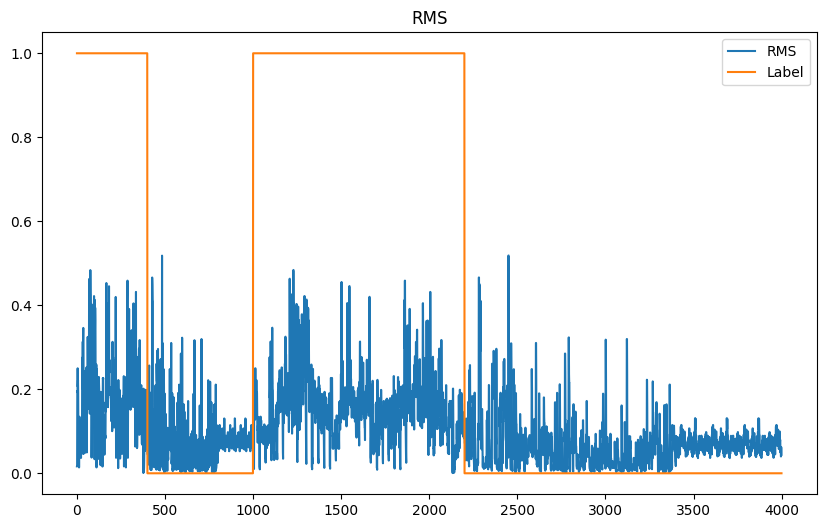

In [6]:
# Visualizing RMS and label
plt.figure(figsize=(10, 6))
plt.title('RMS')
plt.plot(dataset['rms'])
plt.plot(dataset['label'])
plt.legend(['RMS', 'Label'])
plt.show()

It shown that Root Mean Square (RMS) Energy is a good feature to distinguish between emergency and non-emergency audio, because the RMS Energy of emergency audio is relatively higher than non-emergency audio.

#### Feature 2: Chroma Frequencies

In [ ]:
# Count chroma features
chroma_features = [col for col in dataset.columns if "chroma" in col]
print(f'Chroma features: {len(chroma_features)}')

Chroma features: 12


NameError: name 'chroma_features' is not defined

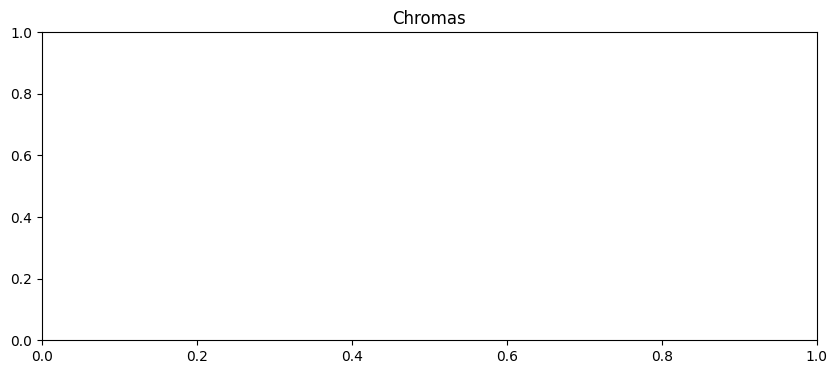

In [7]:
# Visualizing chroma_stft as line plot
plt.figure(figsize=(10, 4))
plt.title("Chromas")
for col in chroma_features:
    plt.plot(dataset[col])
plt.plot(dataset["label"])
plt.show()

Chroma frequencies are also a good feature to distinguish between emergency and non-emergency sounds, since the chroma frequencies of non-emergency sounds are more concentrated than emergency sounds and also relatively higher than emergency sounds.

#### Feature 3: Mel-Frequency Cepstral Coefficients (MFCCs)

In [ ]:
# Count MFCC features
mfcc_features = [col for col in dataset.columns if "mfcc" in col]
print(f'MFCC features: {len(mfcc_features)}')

MFCC features: 20


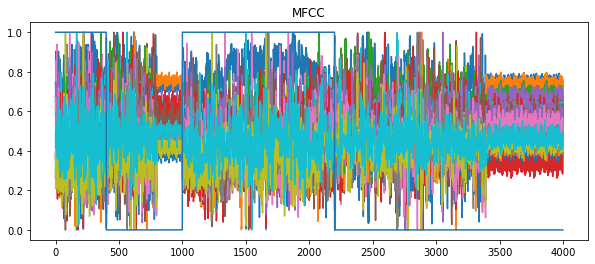

In [ ]:
# Visualizing mfcc as line plot and normalizing the values (visualization purposes)
plt.figure(figsize=(10, 4))
plt.title("MFCC")
for col in mfcc_features:
    # Normalize values into [0, 1]
    plt.plot((dataset[col] - dataset[col].min()) / (dataset[col].max() - dataset[col].min()))
plt.plot(dataset["label"])
plt.show()

Seeing from the plot, using all MFCCs as features is not a good idea, since from the above plot it shows inconsistent results.

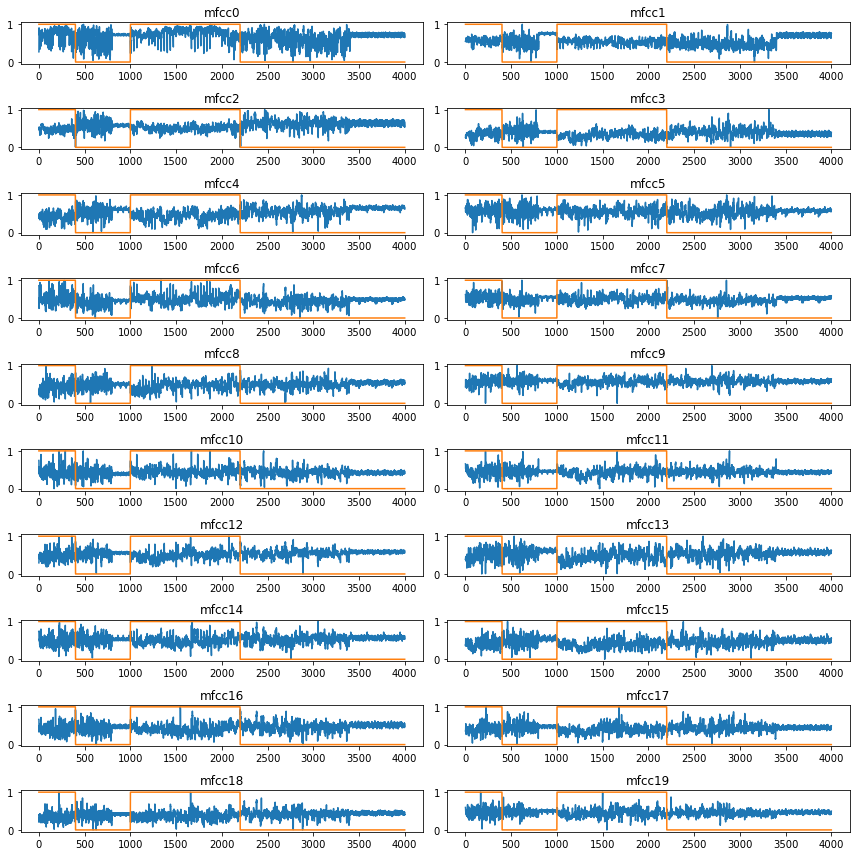

In [ ]:
# Visualizing mfcc as line plot and normalizing the values (visualization purposes)
plt.figure(figsize=(12, 12))
plt.title("MFCC")
for idx, col in enumerate(mfcc_features):
    plt.subplot(10, 2, idx + 1)
    # Normalize values into [0, 1]
    plt.plot((dataset[col] - dataset[col].min()) / (dataset[col].max() - dataset[col].min()))
    plt.plot(dataset["label"])
    plt.title(col)
plt.tight_layout()
plt.show()

Breaking down the MFCCs into each MFCC visualization, it is shown that most of the MFCCs are not good features to distinguish between emergency and non-emergency sounds, since the MFCCs of emergency and non-emergency sounds are inconsistent and similar at some points. So, we won't use any MFCCs as features. Even though, there are some MFCCs that are good features to distinguish between emergency and non-emergency sounds, but we won't use it since it is not consistent.

#### Feature 4: Contrast

In [ ]:
# Count contrast features
contrast_features = [col for col in dataset.columns if "contrast" in col]
print(f'Contrast features: {len(contrast_features)}')

Contrast features: 7


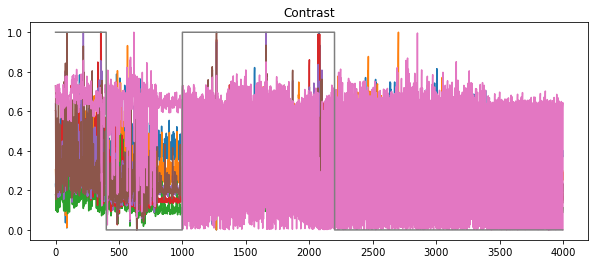

In [ ]:
# Visualizing contrast as line plot and normalizing the values (visualization purposes)
plt.figure(figsize=(10, 4))
plt.title("Contrast")
for col in contrast_features:
    # Normalize values into [0, 1]
    plt.plot((dataset[col] - dataset[col].min()) / (dataset[col].max() - dataset[col].min()))
plt.plot(dataset["label"])
plt.show()

Similar to MFCC, using all contrast as features is not a good idea, since from the above plot it shows inconsistent results, especially shown in above graph.

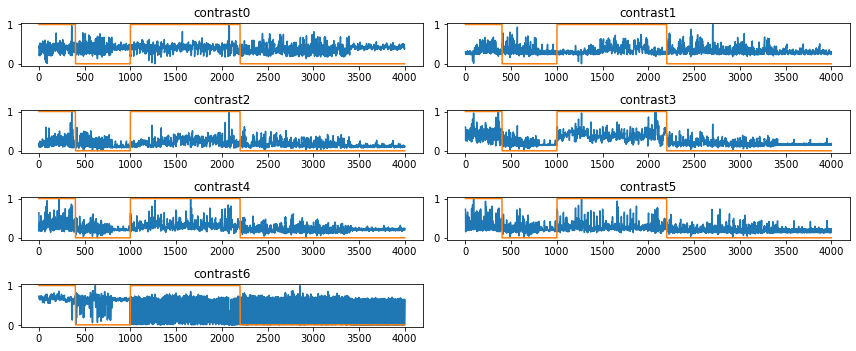

In [ ]:
# Visualizing contrast as line plot and normalizing the values (visualization purposes)
plt.figure(figsize=(12, 12))
plt.title("Contrast")
for idx, col in enumerate(contrast_features):
    plt.subplot(10, 2, idx + 1)
    # Normalize values into [0, 1]
    plt.plot((dataset[col] - dataset[col].min()) / (dataset[col].max() - dataset[col].min()))
    plt.plot(dataset["label"])
    plt.title(col)
plt.tight_layout()
plt.show()

It is shown that contrast 3 and contrast 4 are good features to distinguish between emergency and non-emergency sounds, since the contrast 3 and contrast 4 of emergency sounds are relatively higher than non-emergency sounds.

### Feature Extraction

In [8]:
# Dropping features that are not useful
avoid_features = [
    'label',
    'mfcc2', 
    'mfcc4',
]

for col in avoid_features:
    features = features[features != col]

In [9]:
features

Index(['contrast3', 'chroma10', 'chroma1', 'chroma0', 'chroma11', 'chroma2',
       'chroma8', 'chroma9', 'chroma3', 'rms', 'chroma5', 'chroma4', 'chroma7',
       'chroma6', 'contrast4'],
      dtype='object')

### Splitting Data

In [10]:
# Getting the dependent and independent variables
X = dataset[features].values
y = dataset['label'].values

In [11]:
print(X.shape, y.shape)

(4000, 15) (4000,)


In [12]:
y

array([1, 1, 1, ..., 0, 0, 0], shape=(4000,))

In [13]:
X

array([[31.91501282,  0.16177163,  0.22520441, ...,  0.4856272 ,
         0.43222091, 34.80013689],
       [31.7958422 ,  0.18163332,  0.24781197, ...,  0.42844129,
         0.4943566 , 32.07034068],
       [18.20212933,  0.46200985,  0.53328323, ...,  0.61618251,
         0.64590287, 15.53324814],
       ...,
       [14.0252544 ,  0.8877151 ,  0.83781567, ...,  0.76814927,
         0.76601909, 16.54787505],
       [14.14893648,  0.88754231,  0.82928205, ...,  0.77018309,
         0.7667492 , 16.93667196],
       [15.29554192,  0.8685149 ,  0.7778604 , ...,  0.75462639,
         0.76896656, 17.92940054]], shape=(4000, 15))

In [14]:
# Splitting the dataset into the Training set and Test set
from sklearn.model_selection import train_test_split

# Splitting the dataset into 80% training and 20% test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify=y, random_state=42, shuffle=True)

print("Train:", X_train.shape, y_train.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (3200, 15) (3200,)
Test: (800, 15) (800,)


In [15]:
# Check train and test set distribution
print("Train set distribution:")
print(pd.Series(y_train).value_counts(normalize=True))
print("Test set distribution:")
print(pd.Series(y_test).value_counts(normalize=True))

Train set distribution:
0    0.6
1    0.4
Name: proportion, dtype: float64
Test set distribution:
0    0.6
1    0.4
Name: proportion, dtype: float64


### Feature Scaling

In [16]:
from sklearn.preprocessing import StandardScaler

# Standardize features by removing the mean and scaling to unit variance
sc = StandardScaler()

# Compute the mean and std to be used for later scaling
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [17]:
X_train

array([[-1.07959477,  1.110864  ,  1.11955989, ...,  1.35792334,
         1.3822804 , -1.20142102],
       [ 4.16004966, -1.46040501, -1.89457015, ..., -2.05691984,
        -2.11247617,  4.12516299],
       [-0.5369887 ,  1.11573189,  0.32381946, ...,  1.04272403,
         1.06912006, -0.86074402],
       ...,
       [ 0.57436494, -0.63438705, -0.73025532, ..., -0.36353385,
        -0.61490835, -0.13464102],
       [-0.01404203, -0.65750694, -0.90553151, ..., -0.22781766,
        -0.90262594,  1.06577655],
       [-0.64501482,  0.48963222,  0.19885574, ...,  0.8681717 ,
         1.12296414, -0.290545  ]], shape=(3200, 15))

## Model Training

In [ ]:
# Initializing model score dataframe
model_score = pd.DataFrame(columns=['model', 'cross validation accuracy', 'standard deviations', 'test accuracy'])

In [18]:
# Train and evaluate models using K-fold cross-validation
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.model_selection import cross_val_score, StratifiedKFold


def evaluate(classifier):
    # Applying k-Fold Cross Validation
    k_fold = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

    # Compute cross-validated accuracy score
    cross_val_scores = cross_val_score(classifier, X_train, y_train, cv=k_fold, scoring='accuracy')

    # Print results
    print(f'Cross-validated accuracy score: {cross_val_scores.mean()}')

    # Print standard deviation
    print(f'Standard deviation: {cross_val_scores.std()}')

    # Fitting classifier to the Training set
    classifier.fit(X_train, y_train)

    # Predicting the Test set results
    y_pred = classifier.predict(X_test)

    # Making the Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    print(cm)

    # Accuracy score
    accuracy = accuracy_score(y_test, y_pred)
    print(f'Accuracy: {accuracy}')

    # Adding model score to dataframe
    model_score.loc[len(model_score)] = [classifier.__class__.__name__, cross_val_scores.mean(), cross_val_scores.std(), accuracy]

### Model 1: Logistic Regression

In [19]:
# Training the Logistic Regression model on the Training set
from sklearn.linear_model import LogisticRegression

logistic = LogisticRegression()
evaluate(logistic)

Cross-validated accuracy score: 0.9156249999999998
Standard deviation: 0.01562500000000001
[[442  38]
 [ 32 288]]
Accuracy: 0.9125


NameError: name 'model_score' is not defined

### Model 2: Decision Tree

In [20]:
# Training the Decision Tree Classification model on the Training set
from sklearn.tree import DecisionTreeClassifier

decision_tree = DecisionTreeClassifier(criterion = 'entropy')
evaluate(decision_tree)

Cross-validated accuracy score: 0.9515625
Standard deviation: 0.008643322928712106
[[462  18]
 [ 15 305]]
Accuracy: 0.95875


NameError: name 'model_score' is not defined

### Model 3: Random Forest

In [21]:
# Training the Random Forest Classification model on the Training set
from sklearn.ensemble import RandomForestClassifier

random_forest = RandomForestClassifier(n_estimators = 10, criterion = 'entropy')
evaluate(random_forest)

Cross-validated accuracy score: 0.9659375000000001
Standard deviation: 0.010121334212938534
[[463  17]
 [  7 313]]
Accuracy: 0.97


NameError: name 'model_score' is not defined

### Model 4: Support Vector Machine

In [22]:
# Training the SVM model on the Training set
from sklearn.svm import SVC

svc = SVC(kernel = 'rbf')
evaluate(svc)

Cross-validated accuracy score: 0.9428124999999999
Standard deviation: 0.01581447616109999
[[452  28]
 [ 13 307]]
Accuracy: 0.94875


NameError: name 'model_score' is not defined

### Model 5: Naive Bayes

In [23]:
# Training the Naive Bayes model on the Training set
from sklearn.naive_bayes import GaussianNB

naive_bayes = GaussianNB()
evaluate(naive_bayes)

Cross-validated accuracy score: 0.8246874999999999
Standard deviation: 0.0202257764066055
[[398  82]
 [ 57 263]]
Accuracy: 0.82625


NameError: name 'model_score' is not defined

## Model Evaluation

In [24]:
# Sort model score by test accuracy
model_score.sort_values(by='test accuracy', ascending=False)

NameError: name 'model_score' is not defined

In [ ]:
# Saving the best model
model = model_score.sort_values(by='test accuracy', ascending=False).iloc[0, 0]
print(f'Best model: {model}')

if model == 'LogisticRegression':
    pickle.dump(logistic, open("model.pkl", "wb"))
elif model == 'DecisionTreeClassifier':
    pickle.dump(decision_tree, open("model.pkl", "wb"))
elif model == 'RandomForestClassifier':
    pickle.dump(random_forest, open("model.pkl", "wb"))
elif model == 'SVC':
    pickle.dump(svc, open("model.pkl", "wb"))
elif model == 'GaussianNB':
    pickle.dump(naive_bayes, open("model.pkl", "wb"))

Best model: RandomForestClassifier


## Testing

In [ ]:
# Loading the model
model = pickle.load(open("model.pkl", "rb"))
model

RandomForestClassifier(criterion='entropy', n_estimators=10)

In [ ]:
import librosa

# Extracting features from the y=signal, sr=sr files
def extract_features(signal, sr):
    features = []

    ## Time-domain features
    # ZCR
    zcr = np.mean(librosa.feature.zero_crossing_rate(y=signal).T, axis=0)

    # RMS
    rms = np.mean(librosa.feature.rms(y=signal).T, axis=0)

    ## Frequency-domain features
    # Spectral Centroid
    spec_cent = np.mean(librosa.feature.spectral_centroid(y=signal, sr=sr).T, axis=0)

    # Spectral Bandwidth
    spec_bw = np.mean(librosa.feature.spectral_bandwidth(y=signal, sr=sr).T, axis=0)

    # Spectral Roll-off
    rolloff = np.mean(librosa.feature.spectral_rolloff(y=signal, sr=sr).T, axis=0)
    
    ## Time-frequency domain features
    # Chroma
    stft = np.abs(librosa.stft(y=signal))
    chroma = np.mean(librosa.feature.chroma_stft(S=stft, sr=sr).T, axis=0)

    # MFCC
    mfcc = np.mean(librosa.feature.mfcc(y=signal, sr=sr).T, axis=0)

    # MelSpectrogram
    mel = np.mean(librosa.feature.melspectrogram(y=signal, sr=sr).T, axis=0)

    # Contrast
    contrast = np.mean(librosa.feature.spectral_contrast(S=stft, sr=sr).T, axis=0)

    # Tonnetz
    tonnetz = np.mean(librosa.feature.tonnetz(y=librosa.effects.harmonic(y=signal), sr=sr).T, axis=0)
    
    features.extend(
        [
            zcr,
            rms,
            spec_cent,
            spec_bw,
            rolloff,
            chroma,
            mfcc,
            mel,
            contrast,
            tonnetz,
        ]
    )

    return features

In [ ]:
# Split the features according to its type
def split_features(dataframe):
    # Copy the dataframe
    df_copy = dataframe.copy()

    # Split the single dimensional features according to its type
    df_copy['zcr'] = df_copy['features'].apply(lambda x: float(x[0]))
    df_copy['rms'] = df_copy['features'].apply(lambda x: float(x[1]))
    df_copy['spec_cent'] = df_copy['features'].apply(lambda x: float(x[2]))
    df_copy['spec_bw'] = df_copy['features'].apply(lambda x: float(x[3]))
    df_copy['rolloff'] = df_copy['features'].apply(lambda x: float(x[4]))

    # Split the two dimensional features according to its type
    df_chroma = pd.DataFrame(df_copy['features'].apply(lambda x: x[5]).tolist(), columns=[f"chroma{i}" for i in range(12)])
    df_mfcc = pd.DataFrame(df_copy['features'].apply(lambda x: x[6]).tolist(), columns=[f"mfcc{i}" for i in range(20)])
    df_mel = pd.DataFrame(df_copy['features'].apply(lambda x: x[7]).tolist(), columns=[f"mel{i}" for i in range(128)])
    df_contrast = pd.DataFrame(df_copy['features'].apply(lambda x: x[8]).tolist(), columns=[f"contrast{i}" for i in range(7)])
    df_tonnetz = pd.DataFrame(df_copy['features'].apply(lambda x: x[9]).tolist(), columns=[f"tonnetz{i}" for i in range(6)])

    # Concatenate the features into a single dataframe
    df_features = pd.concat(
        [
            df_copy['zcr'],
            df_copy['rms'],
            df_copy['spec_cent'],
            df_copy['spec_bw'],
            df_copy['rolloff'],
            df_chroma,
            df_mfcc,
            df_mel,
            df_contrast,
            df_tonnetz,
        ],
        axis=1,
    )

    return df_features

In [ ]:
def scale_data(data):
    audio, sr = librosa.load(data, res_type="kaiser_fast")

    # Extracting features from the y=signal, sr=sr files
    extracted_features = extract_features(audio, sr)

    # Split the features according to its type
    df_features = split_features(pd.DataFrame({"features": [extracted_features]}))

    # Select the features that are selected in the training phase except for the label
    features_no_label = features

    df_features = df_features[features_no_label]

    # Standardize features by removing the mean and scaling to unit variance
    df_features = sc.transform(df_features)

    return df_features

In [ ]:
def predict(sound):
    # Scale the data
    scaled_data = scale_data(sound)

    # Predict the label
    label = model.predict(scaled_data)

    # Define the dictionary of labels
    labels = {
        0: "Non-Emergency",
        1: "Emergency",
    }

    # Return the label
    return labels[label[0]]

### Emergency Sound Detection

#### Example 1: Emergency Compilation

In [ ]:
# Load a sample emergency sound
emergency_compilation = './test/emergency/emergency_compilation.wav'

# Predict the label of the sample emergency sound
print(predict(emergency_compilation))

Emergency


#### Example 2: Police Siren

In [ ]:
police_siren = './test/emergency/police.wav'

# Predict the label of the sample emergency sound
print(predict(police_siren))

Emergency


#### Example 3: Ambulance Siren

In [ ]:
ambulance_siren = './test/emergency/ambulance.wav'

# Predict the label of the sample emergency sound
print(predict(ambulance_siren))

Emergency


### Non-Emergency Sound Detection

#### Example 1: Traffic

In [ ]:
# Load a sample non-emergency sound
traffic = './test/non-emergency/traffic.wav'

# Predict the label of the sample non-emergency sound
print(predict(traffic))

Non-Emergency


#### Example 2: Thunder

In [ ]:
thunder = './test/non-emergency/thunder.wav'

#  Predict the label of the sample non-emergency sound
print(predict(thunder))

Non-Emergency


#### Example 3: Bird

In [ ]:
bird = './test/non-emergency/bird.wav'

# Predict the label of the sample non-emergency sound
print(predict(bird))

Non-Emergency
